In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px

%matplotlib inline

Prompts for portfolio construction with Bard and Claude were run through web interface due to the absence of APIs (and/or absence of approval for request for APIs). This notebook contains processing the information.

## Functions

In [4]:
def convert_reponse4_to_df(coutput4):
    df = pd.DataFrame()
    pairs = coutput4.split(',')
    stocks, weights = [], []

    for pair in pairs:
        stock, weight = pair.split(':')

        stocks.append(stock)
        weights.append(float(weight))

    df = pd.DataFrame({'Stock': stocks, 'Weight': weights})

    if not np.isclose(df['Weight'].sum(), 1):
        df['Weight'] = df['Weight'] / df['Weight'].sum()

    return df

In [5]:
def calculate_avg_weights(responses, companies):
    stock_dict = {stock: [] for stock in companies}

    for response in responses:
        pairs = response.split(',')

        for pair in pairs:
            stock, weight = pair.split(':')

            stock = stock.lstrip()
            if "\"" in stock: stock = stock.strip("\"")
            if "\'" in stock: stock = stock.strip("\'")

            weight = weight.lstrip()
            if "\"" in weight: weight = weight.strip("\"")
            if "\'" in weight: weight = weight.strip("\'")

            stock_dict[stock].append(float(weight))

    for s, w in stock_dict.items():
        print(s, w)
    averages = {stock: sum(weights) / len(weights) for stock, weights in stock_dict.items()}
    print(averages)

    df = pd.DataFrame()
    stocks, weights = [], []

    for stock, weight in averages.items():
        stocks.append(stock)
        weights.append(float(weight))

    df = pd.DataFrame({'Stock': stocks, 'Weight': weights})

    if not np.isclose(df['Weight'].sum(), 1):
        df['Weight'] = df['Weight'] / df['Weight'].sum()

    return df



In [6]:
def calculate_weights_by_sector_average(sector_name, coutput4, this_responses, i, model, rerun=False):
    csv_path = f'cached/{model}_avg_weights_assigned/responses15_auto_{sector_name}.csv'

    if os.path.isfile(csv_path) and not rerun:
        print("Reading from local csv file")
        print(pd.read_csv(csv_path))
        return pd.read_csv(csv_path)

    # otherwise calculate avg weights from scratch
    csv_path_read = f'cached/{model}_sectors/stocks15_auto_{sector_name}.csv'

    sector_df = pd.read_csv(csv_path_read)

    temp_df = sector_df[sector_df['IsValid'] == 1]
    input = temp_df['Stocks'].to_list()
    print(input)

    this_responses.append(coutput4)

    data_dict = dict()
    pairs = coutput4.split(',')

    for pair in pairs:
        stock, weight = pair.split(':')

        stock = stock.lstrip()
        if "\"" in stock: stock = stock.strip("\"")
        if "\'" in stock: stock = stock.strip("\'")

        weight = weight.lstrip()
        if "\"" in weight: weight = weight.strip("\"")
        if "\'" in weight: weight = weight.strip("\'")

        data_dict[stock.strip()] = float(weight.strip())


    csv_path_write_avg = f'cached/{model}_avg_weights_response/responses15_auto_{sector_name}.csv'

    if os.path.isfile(csv_path_write_avg):
        print("Adding weights to file")

        existing_df = pd.read_csv(csv_path_write_avg)
        new_df = pd.DataFrame(list(data_dict.items()), columns=['Stock', f'Weight_{i}'])

        # check if the 'asset' column in the existing DataFrame matches the keys in the parsed data
        common_assets = set(existing_df['Stock']).intersection(set(data_dict.keys()))

        existing_df[f'Weight_{i}'] = existing_df['Stock'].map(lambda x: data_dict[x] if x in common_assets else None)

        new_assets = set(data_dict.keys()).difference(set(existing_df['Stock']))
        new_df = new_df[new_df['Stock'].isin(new_assets)]
        
        final_df = pd.concat([existing_df, new_df], ignore_index=True)
        final_df.to_csv(csv_path_write_avg, index=False)

    else:
        print("Creating a file to keep weights from responses")
        new_df = pd.DataFrame(list(data_dict.items()), columns=['Stock', f'Weight_{i}'])
        new_df.to_csv(csv_path_write_avg, index=False)

    return this_responses


In [7]:
sectors = ['information_technology', 'health_care', 'financials', 'consumer_discretionary', \
           'communication_services', 'industrials', 'consumer_staples', 'energy',\
           'utilities', 'real_estate', 'materials']

sector_names = ['Information Technology', 'Health Care', 'Financials', 'Consumer Discretionary', \
           'Communication Services', 'Industrials', 'Consumer Staples', 'Energy',\
           'Utilities', 'Real Estate', 'Materials']

In [ ]:
sector_name = 'energy'
sector_name_full = 'Energy'
sector_ticker = '^GSPE'
full_ticker = 'SP500-10'

In [ ]:
# sector_name = 'materials'
# sector_name_full = 'Materials'
# sector_ticker = '^SP500-15'
# full_ticker = 'SP500-15'

In [ ]:
# sector_name = 'industrials'
# sector_name_full = 'Industrials'
# sector_ticker = '^SP500-20'
# full_ticker = 'SP500-20'

In [ ]:
# sector_name = 'consumer_discretionary'
# sector_name_full = 'Consumer Discretionary'
# sector_ticker = '^SP500-25'
# full_ticker = 'SP500-25'

In [ ]:
# sector_name = 'consumer_staples'
# sector_name_full = 'Consumer Staples'
# sector_ticker = '^SP500-30'
# full_ticker = 'SP500-30'

In [ ]:
# sector_name = 'health_care'
# sector_name_full = 'Health Care'
# sector_ticker = '^SP500-35'
# full_ticker = 'SP500-35'

In [ ]:
# sector_name = 'financials'
# sector_name_full = 'Financials'
# sector_ticker = '^SP500-40'
# full_ticker = 'SP500-40'

In [ ]:
# sector_name = 'information_technology'
# sector_name_full = 'Information Technology'
# sector_ticker = '^SP500-45'
# full_ticker = 'SP500-45'

In [ ]:
# sector_name = 'communication_services'
# sector_name_full = 'Communication Services'
# sector_ticker = '^SP500-50'
# full_ticker = 'SP500-50'

In [ ]:
# sector_name = 'utilities'
# sector_name_full = 'Utilities'
# sector_ticker = '^SP500-55'
# full_ticker = 'SP500-55'

In [8]:
# sector_name = 'real_estate'
# sector_name_full = 'Real Estate'
# sector_ticker = '^SP500-60'
# full_ticker = 'SP500-60'

In [9]:
df = pd.read_csv(f'sector_dfs/{sector_name}.csv')

sp500_df = pd.read_csv('SP500.csv')
companies = sp500_df[sp500_df['GICS Sector'] == sector_name_full]['Symbol']

For Bard and Claude, in order to obtain portfolio from scratch:

Run prompts fos stock selection. Each string of space-separated tickers obtained from each response must be assigned to the variable, from __resp1__ to __resp10__, respectively. After, run the cell and the __responses__ list will be obtained, which contains all the stocks mentioned by LLM. This list will be processed further.

Example of how it would work on Real Estate sector is provided below.

## Bard AI

In [302]:
resp1 = "EQR AVB PSA PLD EQIX VTR ARE BXP EPRT AMT INVH FSV STORE UMW"
resp2 = "DHI LEN PHM AMT ESS PLD O WPM STWD EXR AMT BDX STWD"
resp3 = "DRI LEN KBH EQR ESS SPG AMT WPM NNN LAND EXR AMT WELL AVB STWD"
resp4 = "AMT EQR ESS IRM PLD DOV EXR HST JLL PSA SPG WELL WMC XOM Z"
resp5 = "EQR AVB SUI PLD VTR BXP DHI LEN TOL CBRE RLGY COMPS INVH FSV MAC"
resp6 = "EQR AVB AMT STWD PEZ WELL LAND VTR ESS DRI KBH EXP RESI JLL"
resp7 = "EQR AVB AMT STWD PEZ WELL LAND VTR ESS DRI KBH EXP RESI JLL"
resp8 = "EQR AMT EXR ESS O STWD WELL PLD CCI DOV IRM DRI LEN VTR"
resp9 = "EQR AVB MAA ESS WRE STWD AMT NNN O DOV CPT IRM EQIX WELL"
resp10 = "AMT EQR WELL ESS O STWD IRM DOV CCI EXR AVB MAA"

responses = [resp1, resp2, resp3, resp4, resp5, resp6, resp7, resp8, resp9, resp10]

## Claude 2

In [370]:
resp1 = "AMT PSA DLR EQIX VICI WELL O AVB DRE CCI MAA EXR PLD SBAC HST"
resp2 = "AMT PLD EQIX CCI PSA O WELL AVB SBAC EQR DLR ESS ARE INVH MAA"
resp3 = "AMT CCI EQIX VRTX DLR PLD AVGO AAPL MSFT NVDA JPM UNH GE F TSLA" 
resp4 = "AMT CCI DLR EQIX VICI PLD AVB ESS EQR O WELL VTR MAA UDR SBAC"
resp5 = "AMT EQR CCI PSA PLD DRE AMT COR MAA WELL O NNN SPG AVB BXP ESS VTR HPP"
resp6 = "AMT CCI EQIX PLD O PSA DLR WELL AVB ESS VTR SBAC UDR DRE MAA"
resp7 = "PLD EQIX CCI O VICI SBAC AVB PSA EQR DLR WELL MAA ARE EXR ESS"
resp8 = "VNO AVB EQR PLD EQIX SBAC PSA O DLR CBRE WELL ARE SPG VTR HST"
resp9 = "PLD AVB O DLR EQR WELL SBAC HST ARE VTR MAA REG ESS VNO KIM"
resp10 = "PLD EQIX AMT CCI O DLR WELL SBAC EQR AVB VTR PSA DRE MAA ARE"

responses = [resp1, resp2, resp3, resp4, resp5, resp6, resp7, resp8, resp9, resp10]

## Stock processing

In [371]:
data_dict = {}

for resp in responses:
    tickers = resp.split()
    for ticker in tickers:
        if ticker in data_dict.keys():
            data_dict[ticker] += 1
        else:
            data_dict[ticker] = 1

In [372]:
stock_list = [(key, value) for key, value in data_dict.items()]
stock_list = sorted(stock_list, key=lambda x: x[1], reverse=True)
print(stock_list)

[('PLD', 10), ('DLR', 9), ('WELL', 9), ('O', 9), ('AVB', 9), ('AMT', 8), ('EQIX', 8), ('CCI', 8), ('MAA', 8), ('SBAC', 8), ('PSA', 7), ('EQR', 7), ('ESS', 6), ('VTR', 6), ('ARE', 5), ('DRE', 4), ('VICI', 3), ('HST', 3), ('EXR', 2), ('UDR', 2), ('SPG', 2), ('VNO', 2), ('INVH', 1), ('VRTX', 1), ('AVGO', 1), ('AAPL', 1), ('MSFT', 1), ('NVDA', 1), ('JPM', 1), ('UNH', 1), ('GE', 1), ('F', 1), ('TSLA', 1), ('COR', 1), ('NNN', 1), ('BXP', 1), ('HPP', 1), ('CBRE', 1), ('REG', 1), ('KIM', 1)]


In [373]:
valid_tickers = set(companies)

valid_most_common_stocks = []

for item in stock_list:
    stock, num = item

    if stock in valid_tickers and len(valid_most_common_stocks) < 15:
        valid_most_common_stocks.append(stock)
    elif stock not in valid_tickers:
        print(f"The stock {stock} is not in the valid list of this S&P 500 sector and hence is being discarded.")

if len(valid_most_common_stocks) < 15:
    print("There are not enough valid stocks to reach the desired number of 15 stocks.")

print("The valid most common stocks are: ", valid_most_common_stocks)

# Convert stock_counter to DataFrame and add valid_most_common_stocks as a new column
df = pd.DataFrame.from_dict(data_dict, orient='index', columns=['Count']).reset_index().rename(columns={'index': 'Stocks'})
df['IsValid'] = df['Stocks'].apply(lambda x: 1 if x in valid_most_common_stocks else 0)

df.to_csv(f'claude_sectors/stocks15_auto_{sector_name}.csv', index=False)

The stock DRE is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock VNO is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock VRTX is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock AVGO is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock AAPL is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock MSFT is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock NVDA is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock JPM is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock UNH is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock GE is not in the valid list of this S&P 500 sector and hence is being discarded.
The stock F is not in the valid list of this S&P 500 sector and hence is bei

In [18]:
print('Valid most common stocks:')
print((' ').join(valid_most_common_stocks))

Valid most common stocks:
PLD DLR WELL O AVB AMT EQIX CCI MAA SBAC PSA EQR ESS VTR ARE


In [376]:
responses_weight = []

For Bard and Claude, in order to obtain portfolio weights from scratch:

Run prompts fos weighting the stocks. Each string of comma-separated tickers and weights obtained from each response must be assigned to the variable, from __output0__ to __output4__, respectively. After, run the cell and the __outputs__ list will be obtained, which contains all the stocks mentioned by LLM. This list will be processed further.

Example of how it would work on Real Estate sector is provided below.


In [377]:
coutput0 = "PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.08, AVB: 0.07, AMT: 0.07, EQIX: 0.07, CCI: 0.06, MAA: 0.06, SBAC: 0.05, PSA: 0.05, EQR: 0.05, ESS: 0.04, VTR: 0.04, ARE: 0.04"
coutput1 = "PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.10, AVB: 0.08, AMT: 0.10, EQIX: 0.07, CCI: 0.06, MAA: 0.05, SBAC: 0.04, PSA: 0.03, EQR: 0.05, ESS: 0.04, VTR: 0.03, ARE: 0.03"
coutput2 = "PLD: 0.10, DLR: 0.12, WELL: 0.08, O: 0.15, AVB: 0.09, AMT: 0.11, EQIX: 0.07, CCI: 0.05, MAA: 0.06, SBAC: 0.04, PSA: 0.03, EQR: 0.04, ESS: 0.03, VTR: 0.02, ARE: 0.01"
coutput3 = "PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.08, AVB: 0.07, AMT: 0.07, EQIX: 0.07, CCI: 0.06, MAA: 0.06, SBAC: 0.05, PSA: 0.05, EQR: 0.05, ESS: 0.04, VTR: 0.04, ARE: 0.04"
coutput4 = "PLD: 0.10, DLR: 0.12, WELL: 0.08, O: 0.15, AVB: 0.09, AMT: 0.11, EQIX: 0.07, CCI: 0.06, MAA: 0.05, SBAC: 0.04, PSA: 0.03, EQR: 0.02, ESS: 0.04, VTR: 0.02, ARE: 0.02"
coutputs = [coutput0, coutput1, coutput2, coutput3, coutput4]

In [378]:
for ind, outp in enumerate(coutputs):
    responses_weight = calculate_weights_by_sector_average(sector_name, outp, responses, ind)

['AMT', 'PSA', 'DLR', 'EQIX', 'WELL', 'O', 'AVB', 'CCI', 'MAA', 'PLD', 'SBAC', 'EQR', 'ESS', 'ARE', 'VTR']
Creating a file to keep weights from responses
['AMT', 'PSA', 'DLR', 'EQIX', 'WELL', 'O', 'AVB', 'CCI', 'MAA', 'PLD', 'SBAC', 'EQR', 'ESS', 'ARE', 'VTR']
Adding weights to file
['AMT', 'PSA', 'DLR', 'EQIX', 'WELL', 'O', 'AVB', 'CCI', 'MAA', 'PLD', 'SBAC', 'EQR', 'ESS', 'ARE', 'VTR']
Adding weights to file
['AMT', 'PSA', 'DLR', 'EQIX', 'WELL', 'O', 'AVB', 'CCI', 'MAA', 'PLD', 'SBAC', 'EQR', 'ESS', 'ARE', 'VTR']
Adding weights to file
['AMT', 'PSA', 'DLR', 'EQIX', 'WELL', 'O', 'AVB', 'CCI', 'MAA', 'PLD', 'SBAC', 'EQR', 'ESS', 'ARE', 'VTR']
Adding weights to file


In [379]:
responses_weight = responses_weight[-5:]
responses_weight

['PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.08, AVB: 0.07, AMT: 0.07, EQIX: 0.07, CCI: 0.06, MAA: 0.06, SBAC: 0.05, PSA: 0.05, EQR: 0.05, ESS: 0.04, VTR: 0.04, ARE: 0.04',
 'PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.10, AVB: 0.08, AMT: 0.10, EQIX: 0.07, CCI: 0.06, MAA: 0.05, SBAC: 0.04, PSA: 0.03, EQR: 0.05, ESS: 0.04, VTR: 0.03, ARE: 0.03',
 'PLD: 0.10, DLR: 0.12, WELL: 0.08, O: 0.15, AVB: 0.09, AMT: 0.11, EQIX: 0.07, CCI: 0.05, MAA: 0.06, SBAC: 0.04, PSA: 0.03, EQR: 0.04, ESS: 0.03, VTR: 0.02, ARE: 0.01',
 'PLD: 0.12, DLR: 0.11, WELL: 0.09, O: 0.08, AVB: 0.07, AMT: 0.07, EQIX: 0.07, CCI: 0.06, MAA: 0.06, SBAC: 0.05, PSA: 0.05, EQR: 0.05, ESS: 0.04, VTR: 0.04, ARE: 0.04',
 'PLD: 0.10, DLR: 0.12, WELL: 0.08, O: 0.15, AVB: 0.09, AMT: 0.11, EQIX: 0.07, CCI: 0.06, MAA: 0.05, SBAC: 0.04, PSA: 0.03, EQR: 0.02, ESS: 0.04, VTR: 0.02, ARE: 0.02']

## Average weights

In [380]:
valid_most_common_stocks

['PLD',
 'DLR',
 'WELL',
 'O',
 'AVB',
 'AMT',
 'EQIX',
 'CCI',
 'MAA',
 'SBAC',
 'PSA',
 'EQR',
 'ESS',
 'VTR',
 'ARE']

In [381]:
print("Calculating averages")
avg_weights_response_df = calculate_avg_weights(responses_weight, valid_most_common_stocks)
csv_path_write = f'claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'
avg_weights_response_df.to_csv(csv_path_write, index=False)
avg_weights_response_df


Calculating averages
PLD [0.12, 0.12, 0.1, 0.12, 0.1]
DLR [0.11, 0.11, 0.12, 0.11, 0.12]
WELL [0.09, 0.09, 0.08, 0.09, 0.08]
O [0.08, 0.1, 0.15, 0.08, 0.15]
AVB [0.07, 0.08, 0.09, 0.07, 0.09]
AMT [0.07, 0.1, 0.11, 0.07, 0.11]
EQIX [0.07, 0.07, 0.07, 0.07, 0.07]
CCI [0.06, 0.06, 0.05, 0.06, 0.06]
MAA [0.06, 0.05, 0.06, 0.06, 0.05]
SBAC [0.05, 0.04, 0.04, 0.05, 0.04]
PSA [0.05, 0.03, 0.03, 0.05, 0.03]
EQR [0.05, 0.05, 0.04, 0.05, 0.02]
ESS [0.04, 0.04, 0.03, 0.04, 0.04]
VTR [0.04, 0.03, 0.02, 0.04, 0.02]
ARE [0.04, 0.03, 0.01, 0.04, 0.02]
{'PLD': 0.11199999999999999, 'DLR': 0.11399999999999999, 'WELL': 0.086, 'O': 0.11199999999999999, 'AVB': 0.08, 'AMT': 0.092, 'EQIX': 0.07, 'CCI': 0.057999999999999996, 'MAA': 0.055999999999999994, 'SBAC': 0.044, 'PSA': 0.038, 'EQR': 0.041999999999999996, 'ESS': 0.038, 'VTR': 0.03, 'ARE': 0.027999999999999997}


,Stock,Weight
0,PLD,0.112
1,DLR,0.114
2,WELL,0.086
3,O,0.112
4,AVB,0.080
5,AMT,0.092
6,EQIX,0.070
7,CCI,0.058
8,MAA,0.056
9,SBAC,0.044


In [382]:
avg_weights_response_df.sum()

Stock     PLDDLRWELLOAVBAMTEQIXCCIMAASBACPSAEQRESSVTRARE
Weight                                               1.0
dtype: object

## Analysis

In [383]:
print('num of stocks before selection: ', len(stock_list))

num of stocks before selection:  40


In [385]:
def plot_selected_by_sector(sector):
    csv_path = f'bard_sectors/stocks15_auto_{sector_name}.csv'

    temp_df = pd.read_csv(csv_path)
    temp_df = temp_df.sort_values(by='IsValid', ascending=False)

    stock_counter = temp_df.set_index('Stocks')['Count'].to_dict()
    # print('Number of stocks in the universe before selecting 15: ', len(stock_counter.keys()))
    valid_most_common_stocks = temp_df.loc[temp_df['IsValid'] == 1, 'Stocks'].tolist()

    plt.figure(figsize=(10, 6))

    tickers, counts = zip(*stock_counter.items())

    colors = ['red' if ticker in valid_most_common_stocks else 'blue' for ticker in tickers]

    k_value_case1 = len(valid_most_common_stocks)

    plt.bar(tickers, counts, color=colors)
    plt.xlabel('Stock tickers')
    plt.ylabel('Number of occurrences')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig('GPT_'+str(k_value_case1)+'_instr_universe.eps', format='eps', dpi=1200)
    plt.savefig('GPT_'+str(k_value_case1)+'_instr_universe.png', format='png', dpi=600)
    plt.title(f'Selected stocks in {sector} sector')
    plt.show()

    print(f'Processed {sector} sector')

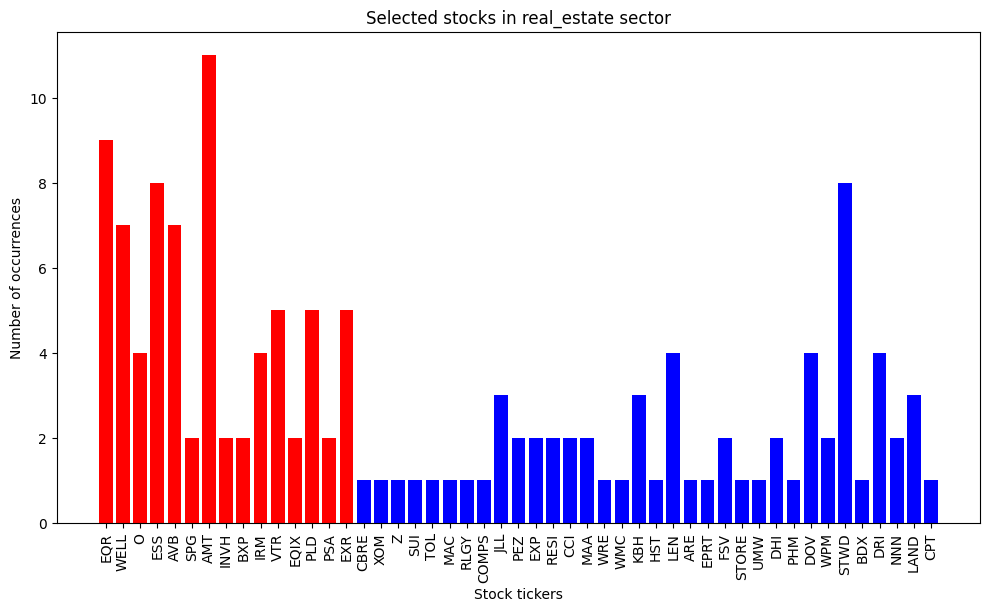

Processed real_estate sector


In [386]:
plot_selected_by_sector(sector_name)

## Stocks outside of sector (Bard) - by sector

In [19]:
with open(f'cached/bard_responses/bard_{sector_name}.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    stocks = []
    for line in lines:
        if ',' in line:
            stock_list = line.split(',')
        else:
            stock_list = line.split(' ')
        stock_list = [s.strip() for s in stock_list]

        stocks.extend(stock_list)

# stocks.remove('')
stocks = set(stocks)
print('Stocks in the universe before selection: ', len(stocks))
stocks

count = 0
for st in stocks:
    if st not in list(companies):
        count += 1
print('Stocks not from the sector index: ', count)

Stocks in the universe before selection:  49
Stocks not from the sector index:  28


## Stocks outside of sector (Claude) - all sectors

In [387]:
for sector_this, sector_name_full_this in zip(sectors, sector_names):
    try:
        csv_path = f'cached/claude_sectors/stocks15_auto_{sector_this}.csv'

        df_count = pd.read_csv(csv_path)

        sp500_df = pd.read_csv('SP500.csv')
        companies = sp500_df[sp500_df['GICS Sector'] == sector_name_full_this]['Symbol']

        counter_invalid = 0
        for stock in df_count['Stocks']:
            if not (stock in list(companies)):
                counter_invalid += 1
                # print(stock)

        print(counter_invalid, sector_name_full_this)
    except:
        continue

8 Information Technology
0 Health Care
2 Financials
11 Consumer Discretionary
18 Communication Services
11 Industrials
1 Consumer Staples
37 Energy
10 Utilities
15 Real Estate
3 Materials


# Weight volatility

In [389]:
csv_path_write_avg = f'cached/claude_avg_weights_response/responses15_auto_{sector_name}.csv'
dfw = pd.read_csv(csv_path_write_avg)

fig = px.box(dfw, x='Stock', y=['Weight_0', 'Weight_1', 'Weight_2', 'Weight_3', 'Weight_4'], points="all",
             title=f"Weight volatility for {full_ticker} {sector_name} sector (claude model)",
             labels={'variable': 'Columns', 'value': 'Weight'})

fig.update_layout(height=600, width=900)
fig.show()
